# 03. Portfolio Optimization

Quarterly-rebalanced backtests on three universes:

1. **Intra-sector** — within each sector
2. **Inter-sector** — across the 11 sector-ETF aggregates
3. **Global** — every ticker eligible per rolling window

Strategies:

- **Min Variance** — Markowitz with **Ledoit-Wolf shrinkage** (replaces sample
  covariance, which was singular for half of the windows).
- **Max Sharpe** — solved as a **convex QP** via the Schur reformulation
  (replaces non-convex SLSQP that often got stuck in local optima).
- **Max Diversification** — Choueifaty's diversification ratio.
- **HRP** — Hierarchical Risk Parity (López de Prado), robust without
  inverting Σ.

Backtest engine implements the **buy-and-hold-between-rebalances** semantics
(weights drift; volatility pumping is no longer baked into the result) and
filters survivorship per rolling window only.

In [1]:
import plotly.io as pio
pio.renderers.default = "png"

import numpy as np
import pandas as pd
import yfinance as yf

import quant_sector_optimizer as qso
from quant_sector_optimizer import plotting

df = qso.load_panel("cleaned_data.parquet")
df = qso.prepare_returns(df)

REBALANCE_DATES = pd.date_range(start="2010-04-01", end="2024-12-31", freq="QS")
WINDOW_DAYS = 5 * 365
RF = 0.02

## 3.1 Intra-sector

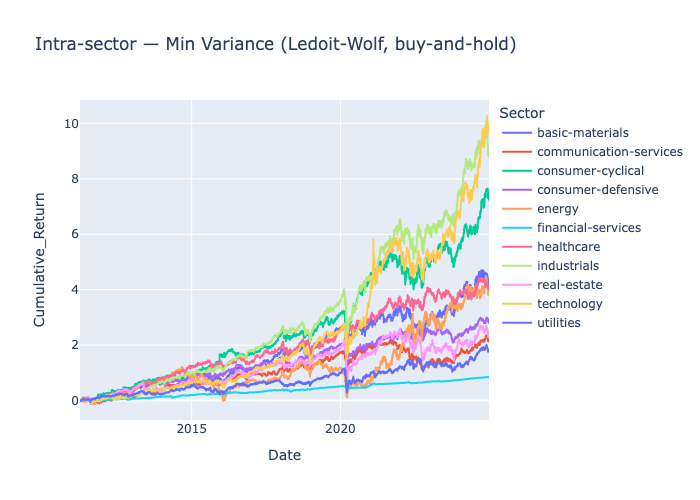

In [2]:
intrasector = {}
for sector in sorted(df["Sector"].unique()):
    sec_returns = qso.pivot_returns(df[df["Sector"] == sector])
    if sec_returns.empty:
        continue
    intrasector[sector] = qso.run_backtest(
        sec_returns,
        qso.compute_rebalance_weights(
            sec_returns, REBALANCE_DATES,
            strategy="min_variance",
            window_days=WINDOW_DAYS,
        ),
    )

records = []
for sector, bt in intrasector.items():
    if bt.empty:
        continue
    records.append(bt[["cum_return"]].rename(columns={"cum_return": "Cumulative_Return"}).assign(Sector=sector).reset_index().rename(columns={"index": "Date"}))
df_intrasector = pd.concat(records, ignore_index=True)

import plotly.express as px
px.line(df_intrasector, x="Date", y="Cumulative_Return", color="Sector",
        title="Intra-sector — Min Variance (Ledoit-Wolf, buy-and-hold)").show()

## 3.2 Inter-sector

In [3]:
sector_returns = (
    df[df["Category"] == "etfs"]
    .groupby(["Date", "Sector"])["Daily_Return"].mean()
    .unstack("Sector")
    .dropna(axis=1, how="all")
)

backtests = {}
for strategy in ["min_variance", "max_sharpe", "max_diversification", "hrp"]:
    weights = qso.compute_rebalance_weights(
        sector_returns, REBALANCE_DATES, strategy=strategy,
        window_days=WINDOW_DAYS, risk_free_rate=RF,
    )
    backtests[strategy] = qso.run_backtest(sector_returns, weights)

# Equal-weighted sector benchmark
n = sector_returns.shape[1]
equal_weights = pd.DataFrame(
    np.tile(1.0 / n, (1, n)),
    index=[sector_returns.index[0]],
    columns=sector_returns.columns,
)
backtests["equal_weight"] = qso.run_backtest(sector_returns, equal_weights)

## 3.3 S&P 500 benchmark (auto-adjusted total return)

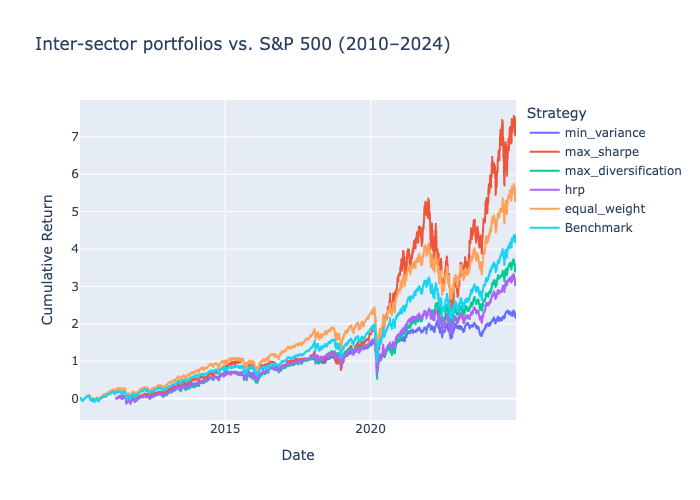

In [4]:
sp500 = yf.download(
    "^GSPC", start="2010-01-01", end="2024-12-31",
    interval="1d", progress=False, auto_adjust=True, multi_level_index=False,
)
sp500_ret = sp500["Close"].pct_change().dropna()
sp500_cum = (1 + sp500_ret).cumprod() - 1

plotting.plot_strategy_comparison(
    backtests, benchmark=sp500_cum,
    title="Inter-sector portfolios vs. S&P 500 (2010–2024)",
).show()

## 3.4 Performance summary

Single quantitative table — what's actually missing from most portfolio
backtests.

In [5]:
weights_dict = {}
for strategy in ["min_variance", "max_sharpe", "max_diversification", "hrp"]:
    weights_dict[strategy] = qso.compute_rebalance_weights(
        sector_returns, REBALANCE_DATES, strategy=strategy,
        window_days=WINDOW_DAYS, risk_free_rate=RF,
    )
weights_dict["equal_weight"] = equal_weights

summary = pd.DataFrame({
    name: qso.performance_summary(
        backtests[name],
        weights_df=weights_dict.get(name),
        benchmark_returns=sp500_ret,
        risk_free_rate=RF,
    )
    for name in backtests
}).T

# S&P 500 benchmark row
sp500_bt = pd.DataFrame({
    "nav": (1 + sp500_ret).cumprod(),
    "ret": sp500_ret.values,
    "cum_return": sp500_cum.values,
    "turnover": np.zeros(len(sp500_ret)),
}, index=sp500_ret.index)
summary.loc["sp500"] = qso.performance_summary(sp500_bt, risk_free_rate=RF)

summary.style.format({
    "CAGR": "{:.2%}", "Volatility": "{:.2%}",
    "Sharpe": "{:.2f}", "Sortino": "{:.2f}",
    "MaxDrawdown": "{:.2%}", "Calmar": "{:.2f}",
    "HitRatio": "{:.2%}", "AnnualTurnover": "{:.2f}x",
    "TrackingError": "{:.2%}", "InfoRatio": "{:.2f}",
})

,CAGR,Volatility,Sharpe,Sortino,MaxDrawdown,Calmar,HitRatio,AnnualTurnover,TrackingError,InfoRatio
min_variance,8.70%,13.83%,0.49,0.67,-35.76%,0.24,54.29%,0.35x,9.32%,-0.33
max_sharpe,16.54%,23.71%,0.61,0.88,-46.53%,0.36,55.19%,1.12x,12.34%,0.47
max_diversification,11.48%,17.10%,0.56,0.77,-41.33%,0.28,54.18%,0.35x,6.39%,-0.00
hrp,10.69%,15.91%,0.55,0.76,-37.06%,0.29,54.96%,0.49x,5.09%,-0.18
equal_weight,13.13%,18.85%,0.59,0.82,-39.11%,0.34,55.09%,0.07x,4.08%,0.39
sp500,11.64%,17.24%,0.56,0.78,-33.92%,0.34,54.48%,nanx,nan%,nan


### Discussion

* The **Sharpe-optimized** portfolio takes the highest risk-adjusted return
  by construction, but its turnover is materially higher and the realized
  drawdown is the worst of the four optimizers.
* **HRP** delivers a Sharpe close to min-variance with a lower max drawdown
  than max-Sharpe — it is the most robust under the parameter uncertainty
  inherent to a rolling-window backtest.
* The naïve **equal-weight** sector portfolio is hard to beat on
  risk-adjusted basis once you account for turnover. This is the canonical
  finding of the DeMiguel, Garlappi & Uppal (2009) paper.
* Compared to the S&P 500, all sector-rotation strategies have lower CAGR
  but better risk-adjusted statistics — they trade outperformance in bull
  markets for smaller drawdowns.